In [1]:
from sympy import *
init_printing()

# Metoda rozdzielania zmiennych (Separation of variables)

## Przykład: równanie Laplace'a  

Funkcja dwóch zmiennych $u(x, y)$ - równanie różniczkowe **cząstkowe** (PDE)
  
$$ \frac{\partial^{2}u}{\partial x^{2}} + \frac{\partial^{2}u}{\partial y^{2}} = 0 \tag{1}$$  

Równoważny zapis: $u_{xx} + u_{yy} = 0$

**Metoda rozdzielania zmiennych**: Zakładamy, że szukana funkcja daje się wyrazić jako iloczyn:  

$$ u(x, y) = X(x)Y(y) \tag{2}$$  
  
(Dlaczego możemy tak założyć? Akurat w tym przypadku wiemy, że to działa - równania różniczkowe cząstkowe 2. i wyższych rzędów są bardzo trudne w rozwiązywaniu i poza dobrze poznanymi przypadkami (takimi jak równanie Laplace'a, falowe, ciepła itp.) ich rozwiązywanie polega zwykle na testowaniu różnych metod. Wiele równań nie ma rozwiązań analitycznych - czyli nie ma żadnej gwarancji, że którakolwiek z metod, takich jak np. rozdzielenia zmiennych, da rezultat. Innymi słowy, przyjmowane na początku założenia, takie jak to wyżej o iloczynie funkcji, mogą się okazać fałszywe - wówczas metoda nie zadziała.)

Podstawiając $(2)$ do $(1)$, otrzymujemy:  

$$ X''(x)Y(y) + X(x)Y''(y) = 0 $$
  
po przekształceniu (rozdzielenie zmiennych za pomocą odpowiedniego dzielenia stron):  
  
$$ \frac{X''(x)}{X(x)} + \frac{Y''(y)}{Y(y)} = 0 $$

Kluczowy moment tej metody rozwiązania: zauważamy, że powyższa suma jest równa zero, gdy obydwa składniki są pewnymi **stałymi** o przeciwnych znakach. Wobec tego przyjmujemy taką stałą $\lambda$, tzw. stałą separacji:
  
$$ \frac{X''(x)}{X(x)} = \lambda, \frac{Y''(y)}{Y(y)} = -\lambda $$
  
$$ \lambda + (-\lambda) = 0$$

Wykonując kilka prostych przekształceń (przeniesienie zmiennych na jedną stronę, pomnożenie przez mianowniki ułamka) uzyskamy w ten sposób dwa równania różniczkowe zwyczajne:

$$ X''(x) - \lambda X(x) = 0 \tag{3}$$  
$$ Y''(y) + \lambda Y(y) = 0 \tag{4}$$

Mamy teraz dwa prostsze problemy do rozwiązania. Możemy teraz rozwiązać obydwa te równania na przykład za pomocą równań charakterystycznych.

In [2]:
# uwaga: slowo 'lambda' jest slowem kluczowym w Pythonie, dlatego zmienna nalezy nazwac inaczej, np. lmbd
x, y, lmbd, r = symbols('x y lambda r')
u, X, Y = map(Function, 'uXY')

### Pierwszy przypadek: $\lambda > 0 $  

Równanie charakterystyczne dla $(3): r^2 - \lambda = 0, r_1 = \sqrt{\lambda}, r_2 = -\sqrt{\lambda}$  
Równanie charakterystyczne dla $(4): r^2 + \lambda = 0, r_1 = i\sqrt{\lambda}, r_2 = -i\sqrt{\lambda}$

Rozwiązania, które **powinniśmy** uzyskać:  
$X(x) = C_1 e^{\sqrt{\lambda}x} + C_2 e^{-\sqrt{\lambda}x} $  
$Y(y) = C_3 \cos(\sqrt{\lambda} y) + C_4 \sin(\sqrt{\lambda} y) $

Można za pomocą Sympy pomóc sobie w rozwiązaniu równania charakterystycznego i podstawić znalezione rozwiązania do wzoru na rozwiązanie równania różniczkowego:

In [3]:
solve(Eq(r**2 - lmbd, 0), r)

In [4]:
solve(Eq(r**2 + lmbd, 0), r)

Niestety, czasem trzeba jednak wiedzieć, czego szukamy - drugie rozwiązanie nie jest do końca właściwe bez dodania założenia, że $\lambda$ jest dodatnie:

In [5]:
# definiujemy na nowo zmienną lambda, tym razem zaznaczając, że jest dodatnie
lmbd = symbols('lambda', positive=True)

In [6]:
solve(Eq(r**2 + lmbd, 0), r)

Można też od razu spróbować rozwiązać równania rózniczkowe, jednak tutaj też trzeba uważać na założenia i uzyskane wyniki. Definiując ponownie $\lambda$ bez założeń co do znaku, znów uzyskamy zbyt ogólne rozwiązanie na $Y(y)$:

In [7]:
# redefinicja lambda bez dodatkowych założeń
lmbd = symbols('lambda')

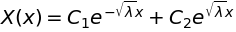

In [8]:
dsolve(Eq(diff(X(x), x, 2) - lmbd*X(x), 0))

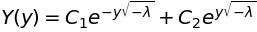

In [9]:
dsolve(Eq(diff(Y(y), y, 2) + lmbd*Y(y), 0))

Poprawiamy:

In [10]:
lmbd = symbols('lambda', positive=True)

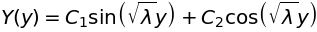

In [11]:
dsolve(Eq(diff(Y(y), y, 2) + lmbd*Y(y), 0))

**Uwaga na oznaczenia stałych** - poszczególne rozwiązania równań zwrócone przez Sympy są niezależne od siebie, a więc znalezienie np. rozwiązania dla stałej całkowania $C_1$ z równania na $X(x)$ nie oznacza, że możemy tę wartość podstawić do równania $Y(y)$ (innymi słowy, dla każdego z równań szukamy stałych całkowania niezależnie).

### Drugi przypadek: $\lambda = 0 $  

$X''(x) - 0*X(x) = 0 → X''(x) = 0 → X(x) = A_1 x + B_1 $  
$Y''(y) + 0*Y(y) = 0 → Y''(y) = 0 → Y(y) = A_2 y + B_2 $  

In [12]:
dsolve(Eq(diff(X(x), x, 2), 0))

### Trzeci przypadek: $\lambda < 0 $  

Równanie charakterystyczne dla $(3): r^2 + \lambda = 0, r_1 = i\sqrt{\lambda}, r_2 = -i\sqrt{\lambda}$  
Równanie charakterystyczne dla $(4): r^2 - \lambda = 0, r_1 = \sqrt{\lambda}, r_2 = -\sqrt{\lambda}$  

Przypadek bardzo podobny do pierwszego - równanie charakterystyczne dla $X(x)$ z pierwszego przypadku staje się równaniem charakterystycznym dla $Y(y)$ i na odwrót.

Rozwiązania:  
$X(x) = C_1 \cos(\sqrt{-\lambda} x) + C_2 \sin(\sqrt{-\lambda} x)  $  
$Y(y) = C_3 e^{\sqrt{-\lambda}y} + C_4 e^{-\sqrt{-\lambda}y}  $

Rozwiązanie programowe, podobnie jak w pierwszym przypadku, wymaga od nas dodania odpowiedniego założenia nt. zmiennej $\lambda$:

In [22]:
lmbd = symbols('lambda', positive=True)
dsolve(Eq(diff(X(x), x, 2) + lmbd*X(x), 0))

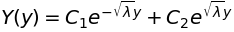

In [24]:
dsolve(Eq(diff(Y(y), y, 2) - lmbd*Y(y), 0))